
---
# Drug Target Interaction Prediction
---

Predicting Drug Target Interactions (DTIs) is crucial for drug discovery and repurposing. Traditional experimental methods are often time-consuming and costly. Computational approaches aim to efficiently identify potential interactions between drug compounds and target proteins, thereby accelerating the drug development process.

## Table of Contents

1. [Setting up the Environment](#setting-up-the-environment)  
   - [Importing the Required Packages](#importing-the-required-packages)  
   - [Detecting the GPU](#detecting-the-gpu)  
   - [Defining the Directory Structure](#defining-the-directory-structure)

2. [Generating Drug Images and Protein Contact Maps](#generating-drug-images-and-protein-contact-maps)  
   - [Helper Functions](#helper-functions)  
     - [`load_dataset`](#loaddataset)  
     - [`display_molecule`](#display_molecule)  
     - [`save_image`](#save_image)  
   - [Storing Unique Drugs and Proteins in DataFrames](#storing-unique-drugs-and-proteins-in-dataframes)  
   - [Saving the Drug Molecule Images](#saving-the-drug-molecule-images)  
   - [Saving the Protein Contact Maps](#saving-the-protein-contact-maps)  
   - [Displaying a Sample Drug Molecule](#displaying-a-sample-drug-molecule)  
   - [Visualizing a Sample Protein Contact Map](#visualizing-a-sample-protein-contact-map)

3. [Extracting Topological Features from Images and Maps](#extracting-topological-features-from-images-and-maps)  
   - [Retrieving Drug Embeddings](#retrieving-drug-embeddings)  
   - [Saving Drug Embeddings](#saving-drug-embeddings)  
   - [Retrieving Protein Embeddings](#retrieving-protein-embeddings)  
   - [Saving Protein Embeddings](#saving-protein-embeddings)

4. [Generating Embeddings for Drugs and Proteins using LLMs](#generating-embeddings-for-drugs-and-proteins-using-llms)  
   - [Drug Embeddings using ChemBERTa](#drug-embeddings-using-chemberta)  
     - [Helper Class](#helper-class-chemberta)  
     - [Extracting the Drug Embeddings](#extracting-the-drug-embeddings)  
     - [Saving the Drug Embeddings](#saving-the-drug-embeddings-chemberta)  
   - [Protein Embeddings using ProtT5](#protein-embeddings-using-prott5)  
     - [Helper Class](#helper-class-prott5)  
     - [Extracting the Protein Embeddings](#extracting-the-protein-embeddings)  
     - [Saving the Protein Embeddings](#saving-the-protein-embeddings-prott5)


# 1. Setting up the Environment
---

## 1.1 Importing the Required Packages

In [ ]:
import os
import re
import requests
import gc
from collections import Counter
from pathlib import Path
from tqdm import tqdm
from itertools import islice

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display  

from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, recall_score, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.cuda.amp import autocast

from torch_geometric.nn import SAGEConv, to_hetero, BatchNorm
from torch_geometric.loader import DataLoader 
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T

from transformers import T5Tokenizer, T5EncoderModel, AutoTokenizer, AutoModel

from huggingface_hub import configure_http_backend

from rdkit import Chem
from rdkit.Chem import Draw

import esm

from gtda.homology import CubicalPersistence
from gtda.diagrams import BettiCurve, PersistenceLandscape

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [2]:
def backend_factory() -> requests.Session:
    session = requests.Session()
    session.verify = False
    return session

configure_http_backend(backend_factory=backend_factory)

## 1.2 Detecting the GPU

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## 1.3 Defining the Directory Structure

In [4]:
working_dir = Path("/home/user/Music/dont_touch/dti")
data_dir = working_dir / "data"

dataset_dirs = {"biosnap_random": data_dir / "biosnap/random"}

out_dir_mol = working_dir / "images" / "molecules"
out_dir_mol.mkdir(parents=True, exist_ok=True)

out_dir_prot = working_dir / "images" / "contacts"
os.makedirs(out_dir_prot, exist_ok=True)

out_dir_emb = working_dir/ "embeddings"
out_dir_emb.mkdir(parents=True, exist_ok=True)

out_dir_emb_s = out_dir_emb / "structural" 
out_dir_emb_s.mkdir(parents=True, exist_ok=True)

out_dir_emb_s_drug = out_dir_emb / "structural" / "drugs"
out_dir_emb_s_drug.mkdir(parents=True, exist_ok=True)

out_dir_emb_s_prot = out_dir_emb / "structural" / "proteins"
out_dir_emb_s_prot.mkdir(parents=True, exist_ok=True)

out_dir_emb_se = out_dir_emb / "semantic" 
out_dir_emb_se.mkdir(parents=True, exist_ok=True)

out_dir_emb_se_drug = out_dir_emb / "semantic" / "drugs"
out_dir_emb_se_drug.mkdir(parents=True, exist_ok=True)

out_dir_emb_se_prot = out_dir_emb / "semantic" / "proteins"
out_dir_emb_se_prot.mkdir(parents=True, exist_ok=True)

dataset = "biosnap_random"

# 2. Generating Drug Images and Protein Contact Maps
---

## 2.1 Helper Functions

In [4]:
def load_dataset(dataset):
    data_dir = working_dir / "data"

    dataset_dirs = {
        "biosnap_random": data_dir / "biosnap/random",
        "human_random": data_dir / "human/random",
        "human_cold": data_dir / "human/cold"}  

    dataset_path = dataset_dirs[dataset]    

    train_path = dataset_path / "train.csv"
    val_path = dataset_path / "val.csv"
    test_path = dataset_path / "test.csv"  

    train = pd.read_csv(train_path)
    val = pd.read_csv(val_path)
    test = pd.read_csv(test_path)

    dataset_data = pd.concat([train, val, test], ignore_index=True)

    return dataset_data


def display_molecule(smile_string):
    molecule = Chem.MolFromSmiles(smile_string)
    if molecule is None:
        print("⚠️The string is invalid⚠️")
        return

    Chem.rdDepictor.Compute2DCoords(molecule)
    image = Draw.MolToImage(molecule, kekulize=True, size=(400, 400))
    
    display(image)


def save_image(idx, smile_string, out_dir_mol):
    molecule = Chem.MolFromSmiles(smile_string)
    if molecule is None:
        raise ValueError("⚠️The string is invalid⚠️")
    
    Chem.rdDepictor.Compute2DCoords(molecule)
    saving_path = os.path.join(out_dir_mol, f"{idx}.png")

    Draw.MolToFile(molecule, saving_path, kekulize=True, size=(256, 256))

## 2.2 Storing Unique Drugs and Proteins in DataFrames

In [5]:
data = load_dataset(dataset)
drugs = pd.DataFrame(data['SMILES'].unique(), columns=['SMILES']).reset_index(drop=True)
proteins = pd.DataFrame(data['Protein'].unique(), columns=['Protein']).reset_index(drop=True)

## 2.3 Saving the Drug Molecule Images 

In [6]:
for idx, r in drugs.iloc[:2400].iterrows():
    smile_string = r["SMILES"]
    save_image(idx, smile_string, out_dir_mol)

print(f"🧬 Molecule images have been saved ✅" )

[17:38:30] Conflicting single bond directions around double bond at index 46.
[17:38:30]   BondStereo set to STEREONONE and single bond directions set to NONE.


🧬 Molecule images have been saved ✅


## 2.4 Saving the Protein Contact Maps

In [ ]:
model, alphabet = esm.pretrained.esm2_t12_35M_UR50D()
model = model.to(device)
batch_converter = alphabet.get_batch_converter()
model.half() 
model.eval()

data = [(str(idx), seq.strip()[:2000]) for idx, seq in proteins["Protein"].items()]
data = data[:2400]

batch_size = 1
for i in tqdm(range(0, len(data), batch_size)):
    batch_data = data[i:i + batch_size]
    batch_labels, batch_strs, batch_tokens = batch_converter(batch_data)
    batch_tokens = batch_tokens.to(device)

    with torch.no_grad():
        results = model(batch_tokens, repr_layers=[12], return_contacts=True)

    batch_lens = (batch_tokens!=alphabet.padding_idx).sum(1)

    for (label, seq), tokens_len, attn_contacts in zip(batch_data, batch_lens, results["contacts"]):
        attn_contacts = attn_contacts[:tokens_len, :tokens_len].cpu()  
        figure, ax = plt.subplots(figsize=(3.0, 3.0), dpi=200)
        ax.matshow(attn_contacts, cmap='cividis')  
        ax.axis('off')  
        ax.set_facecolor('black') 
        figure.savefig(os.path.join(out_dir_prot, f"{label}.png"), bbox_inches='tight', transparent=True)
        plt.close(figure)
        
    torch.cuda.empty_cache()

print(f"📡 Contact maps saved 📁")

100%|██████████| 2181/2181 [05:23<00:00,  6.75it/s]

📡 Contact maps saved 📁


## 2.5 Displaying a Sample Drug Molecule

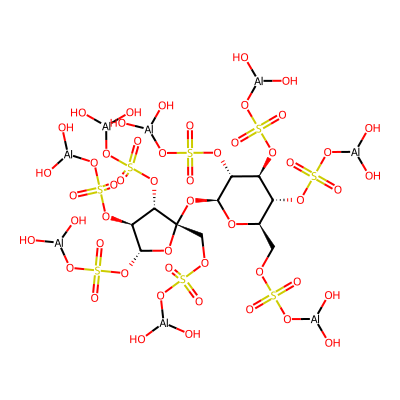

In [8]:
smile_string = drugs['SMILES'][44] 
display_molecule(smile_string)

## 2.6 Visualizing a Sample Protein Contact Map

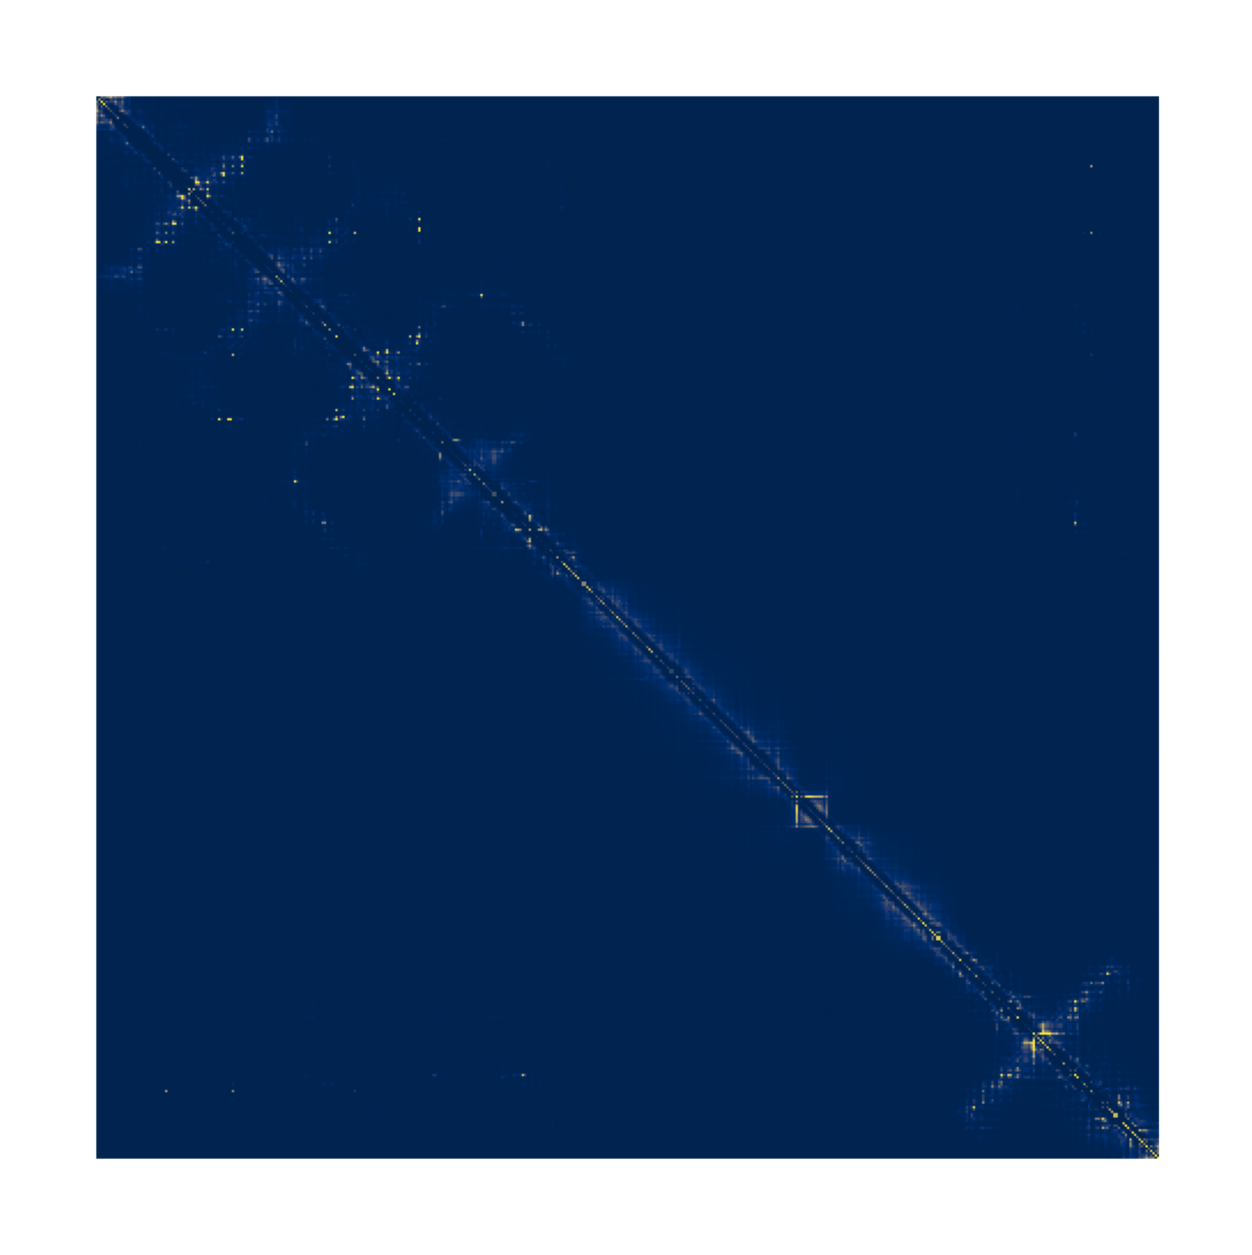

In [9]:
image_path = os.path.join(out_dir_prot, "44.png")

image = Image.open(image_path)
figure, ax = plt.subplots(figsize=(3, 3), dpi=500)

plt.imshow(image)
plt.axis('off')  
plt.show()

# 3. Extracting Topological Features from Images and Maps
--- 

## 3.1 Retrieving Drug Embeddings

In [ ]:
persistence = CubicalPersistence(n_jobs=-1)
BC = BettiCurve(n_bins=50, n_jobs=-1)
PL = PersistenceLandscape(n_bins=100, n_jobs=-1)

drug_feature_data = []

for photo in tqdm(os.listdir(out_dir_mol), desc="Processing images..."):
    if photo.endswith(".png"):
        image_path = os.path.join(out_dir_mol, photo)
        drug_name = os.path.splitext(photo)[0]
        
        image = Image.open(image_path)
        channels = {
            "gray": np.array(image.convert("L"))[None, :, :],
            "red": np.array(image)[:, :, 0][None, :, :],
            "green": np.array(image)[:, :, 1][None, :, :],
            "blue": np.array(image)[:, :, 2][None, :, :]
        }
        
        drug_features = {}
        
        for channel_name, channel_data in channels.items():
            diagrams = persistence.fit_transform(channel_data)

            bc_features = BC.fit_transform(diagrams)
            bc_features_flatten = np.reshape(bc_features, -1)

            pl_features = PL.fit_transform(diagrams)
            pl_features_flatten = np.reshape(pl_features, -1)
           
            combined_features = np.concatenate([bc_features_flatten, pl_features_flatten])
            drug_features[channel_name] = combined_features
        
        final_features_drug = np.concatenate([
            drug_features["gray"],
            drug_features["red"],
            drug_features["green"],
            drug_features["blue"]
        ])
        drug_feature_data.append({"drug_name": drug_name, "molecule_structural_embedding": final_features_drug})

Processing images...: 100%|██████████| 2400/2400 [39:49<00:00,  1.00it/s]


## 3.2 Saving Drug Embeddings

In [17]:
df_drug_emb_s = pd.DataFrame(drug_feature_data)

drug_embeddings_s = np.array(df_drug_emb_s['molecule_structural_embedding'].tolist())  
drug_names = np.array(df_drug_emb_s['drug_name'].tolist(), dtype=str)  

np.save(os.path.join(out_dir_emb_s_drug, "molecule_image_embeddings.npy"), drug_embeddings_s)
np.save(os.path.join(out_dir_emb_s_drug, "molecule_names.npy"), drug_names)

print("💾 Drug names and structural embeddings have been saved successfully 💾")

💾 Drug names and structural embeddings have been saved successfully 💾


## 3.3 Retrieving Protein Embeddings

In [ ]:
cubical_persistence = CubicalPersistence(n_jobs=-1)
BC = BettiCurve(n_bins=50, n_jobs=-1)
PL = PersistenceLandscape(n_bins=100, n_jobs=-1)

prot_feature_data = []

for filename in tqdm(os.listdir(out_dir_prot), desc="Processing maps..."):
    if filename.endswith(".png"):
        image_path = os.path.join(out_dir_prot, filename)
        drug_name = os.path.splitext(filename)[0]
        
        image = Image.open(image_path)
        channels = {
            "gray": np.array(image.convert("L"))[None, :, :],
            "red": np.array(image)[:, :, 0][None, :, :],
            "green": np.array(image)[:, :, 1][None, :, :],
            "blue": np.array(image)[:, :, 2][None, :, :]
        }
        
        prot_features = {}
        
        for channel_name, channel_data in channels.items():
            persistence_diagrams = cubical_persistence.fit_transform(channel_data)

            bc_features = BC.fit_transform(persistence_diagrams)
            bc_features_flatten = np.reshape(bc_features, -1)

            pl_features = PL.fit_transform(persistence_diagrams)
            pl_features_flatten = np.reshape(pl_features, -1)
           
            combined_features = np.concatenate([bc_features_flatten, pl_features_flatten])
            prot_features[channel_name] = combined_features
        
        final_features_prot = np.concatenate([
            prot_features["gray"],
            prot_features["red"],
            prot_features["green"],
            prot_features["blue"]
        ])
        prot_feature_data.append({"protein_index": drug_name, "protein_structural_embedding": final_features_prot})

Processing maps...: 100%|██████████| 2181/2181 [2:13:50<00:00,  3.68s/it]  


## 3.4 Saving Protein Embeddings

In [21]:
df_prot_emb_s = pd.DataFrame(prot_feature_data)

prot_embeddings_s = np.array(df_prot_emb_s['protein_structural_embedding'].tolist())  
prot_names = np.array(df_prot_emb_s['protein_index'].tolist(), dtype=str)  

np.save(os.path.join(out_dir_emb_s_prot, "protein_contact_embeddings.npy"), prot_embeddings_s)
np.save(os.path.join(out_dir_emb_s_prot, "protein_index.npy"), prot_names)

print("💾 Protein indices and structural embeddings have been saved successfully 💾")

💾 Protein indices and structural embeddings have been saved successfully 💾


# 4. Generating Embeddings for Drugs and Proteins using LLMs
---

## 4.1 Drug Embeddings using ChemBERTa

### 4.1.1 Helper Class

In [4]:
class DrugEmbeddings:
    def __init__(self, model_name="seyonec/ChemBERTa-zinc-base-v1", device=None):
        self.device = device if device else torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        print(f"🚀 Loading ChemBERTa model from: {model_name} on device: {self.device} 🚀🧠")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device).eval()


    def canonicalize(self, smi):
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is not None:
                return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)
            else:
                return None
        except Exception:
            return None


    def batch_split(self, data, batch_size=8):
        for i in range(0, len(data), batch_size):
            yield data[i:i+batch_size]


    def embed(self, smiles, batch_size=8):
        embeddings_list = []
        for batch in tqdm(list(self.batch_split(smiles, batch_size)), desc="Processing batches"):
            encodings = self.tokenizer(batch, padding=True, return_tensors="pt")
            encodings = {k: v.to(self.device) for k, v in encodings.items()}

            with torch.no_grad():
                outputs = self.model(**encodings)

            last_hidden = outputs.last_hidden_state
            attention_mask = encodings["attention_mask"].unsqueeze(-1)

            embeddings = (last_hidden * attention_mask).sum(1) / torch.clamp(attention_mask.sum(1), min=1e-9)
            embeddings_list.append(embeddings.cpu().numpy())

            del encodings, outputs, last_hidden, attention_mask, embeddings
            gc.collect()
            torch.cuda.empty_cache()
        return np.concatenate(embeddings_list, axis=0)


    def process_and_save(self, data, output_dir, dataset_name):
        if "SMILES" not in data.columns:
            raise ValueError("Dataset does not contain a 'SMILES' column.")

        output_dir = out_dir_emb_se_drug

        unique_smiles = data["SMILES"].unique()
        canonical_smiles = [self.canonicalize(smi) for smi in unique_smiles]
        valid_indices = [i for i, s in enumerate(canonical_smiles) if s is not None]
        valid_original = [unique_smiles[i] for i in valid_indices]
        valid_canonical = [canonical_smiles[i] for i in valid_indices]

        if not valid_canonical:
            print("⚠️ No valid SMILES strings found. Skipping embedding extraction 🧪❌")
            return

        print(f"🧬 Extracting embeddings for {len(valid_canonical)} valid SMILES in {dataset_name} 🔍")
        embeddings = self.embed(valid_canonical)

        np.save(output_dir / f"{dataset_name}_smiles.npy", np.array(valid_original))
        np.save(output_dir / f"{dataset_name}_canonical_smiles.npy", np.array(valid_canonical))
        np.save(output_dir / f"{dataset_name}_drug_embeddings.npy", embeddings)
        print(f"💾 Saved {len(embeddings)} drug embeddings ✅")

### 4.1.2 Extracting the Drug Embeddings

In [5]:
drug_embeddings = DrugEmbeddings()

for dataset_name, dataset_path in dataset_dirs.items():
    dataset_path = Path(dataset_path)

    train_file = dataset_path / "train.csv"
    val_file = dataset_path / "val.csv"
    test_file = dataset_path / "test.csv"

    if train_file.exists() and val_file.exists() and test_file.exists():
        train_data = pd.read_csv(train_file)
        val_data = pd.read_csv(val_file)
        test_data = pd.read_csv(test_file)
        full_data = pd.concat([train_data, val_data, test_data], ignore_index=True)

        if "SMILES" in full_data.columns:
            drug_embeddings.process_and_save(full_data, out_dir_emb_se_drug, dataset_name=dataset_name)
        else:
            print(f"⚠️ No 'SMILES' column found in the dataset: {dataset_name} ❌")

    else:
        print(f"⏭️ Skipping {dataset_name}: Missing one or more of train.csv, val.csv, or test.csv 📁")

🚀 Loading ChemBERTa model from: seyonec/ChemBERTa-zinc-base-v1 on device: cuda:0 🚀🧠


[20:49:22] Unusual charge on atom 0 number of radical electrons set to zero


🧬 Extracting embeddings for 4505 valid SMILES in biosnap_random 🔍


Processing batches: 100%|██████████| 564/564 [03:25<00:00,  2.75it/s]


💾 Saved 4505 drug embeddings ✅


### 4.1.3 Saving the Drug Embeddings

In [6]:
smile_names = np.load(out_dir_emb_se_drug / f"biosnap_random_smiles.npy", allow_pickle=True)
can_smile_names = np.load(out_dir_emb_se_drug / f"biosnap_random_canonical_smiles.npy", allow_pickle=True)
drug_embeddings = np.load(out_dir_emb_se_drug / f"biosnap_random_drug_embeddings.npy", allow_pickle=True)

df_drug_emb_se = pd.DataFrame({ 'smiles': smile_names, 'can_smiles': can_smile_names, 'drug_llm_embeddings': drug_embeddings.tolist()})

## 4.2 Protein Embeddings usinf ProtT5

### 4.2.1 Helper Class

In [9]:
class ProteinEmbeddings:
    def __init__(self, device=None):
        self.device = device if device else torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        self.model_name = "Rostlab/prot_t5_xl_half_uniref50-enc"
        self.tokenizer = T5Tokenizer.from_pretrained(self.model_name, do_lower_case=False, legacy=True)
        self.model = T5EncoderModel.from_pretrained(self.model_name).to(self.device).eval()


    def get_embeddings_batch(self, seqs):
        batch_sequences = [" ".join(list(re.sub(r"[UZOB]", "X", seq))) for seq in seqs]
        ids = self.tokenizer.batch_encode_plus(
            batch_sequences, 
            add_special_tokens=True, 
            padding="longest",
            max_length=1024,    
            truncation=True
        )
        input_ids = torch.tensor(ids['input_ids']).to(self.device)
        attention_mask = torch.tensor(ids['attention_mask']).to(self.device)

        try:
            with torch.no_grad():
                embedding_repr = self.model(input_ids=input_ids, attention_mask=attention_mask)

            last_hidden_state = embedding_repr.last_hidden_state 
            batch_embeddings = [last_hidden_state[i].mean(dim=0).detach().cpu().numpy() for i in range(last_hidden_state.shape[0])]
            return batch_embeddings
        finally:
            del input_ids, attention_mask, embedding_repr, last_hidden_state
            gc.collect()
            torch.cuda.empty_cache()


    def process_and_save(self, data, output_dir, dataset_name):
        output_dir = out_dir_emb_se_prot

        unique_sequences = data['Protein'].unique()
        sequence_embeddings = []
        
        batch_size = 8
        for i in tqdm(range(0, len(unique_sequences), batch_size), desc=f"Processing sequences in {dataset_name}"):
            batch = unique_sequences[i:i + batch_size]
            embeddings = self.get_embeddings_batch(batch)
            sequence_embeddings.extend(embeddings)

        embeddings_array = np.array(sequence_embeddings)
        np.save(output_dir / f"{dataset_name}_target_sequences.npy", unique_sequences)
        np.save(output_dir / f"{dataset_name}_sequence_embeddings.npy", embeddings_array)

### 4.2.2 Extracting the Protein Embeddings

In [10]:
protein_embeddings = ProteinEmbeddings()
all_datasets = {}

for dataset_name, dataset_path in dataset_dirs.items():
    dataset_path = Path(dataset_path)

    train_path = dataset_path / "train.csv"
    val_path = dataset_path / "val.csv"
    test_path = dataset_path / "test.csv"

    if train_path.exists() and val_path.exists() and test_path.exists():
        train = pd.read_csv(train_path)
        val = pd.read_csv(val_path)
        test = pd.read_csv(test_path)

        dataset_data = pd.concat([train, val, test], ignore_index=True)
        all_datasets[dataset_name] = dataset_data

        protein_embeddings.process_and_save(dataset_data, out_dir_emb_se_prot, dataset_name=dataset_name)

        print(f"✅ Successfully embedded the {dataset_name} dataset.")
    else:
        print(f"⚠️ Skipping **{dataset_name}**: Missing one or more files (train.csv, val.csv, test.csv) ❌")

Processing sequences in biosnap_random: 100%|██████████| 273/273 [09:13<00:00,  2.03s/it]

✅ Successfully embedded the biosnap_random dataset.


### 4.2.3 Saving the Protein Embeddings

In [11]:
sequences_names = np.load(out_dir_emb_se_prot / f"biosnap_random_target_sequences.npy", allow_pickle=True)
prot_embeddings_se = np.load(out_dir_emb_se_prot / f"biosnap_random_sequence_embeddings.npy", allow_pickle=True)

df_prot_emb_se = pd.DataFrame({'sequences': sequences_names, 'protein_llm_embeddings': prot_embeddings_se.tolist() })